Titanic data predict whether the person has survived classification based problem.
LR, DT, KNN
Data processing. Missing data has to be imputed
Standard scalar.


In [57]:
##data analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns
#standard Scalar.
from sklearn.preprocessing import StandardScaler

#KNN
from sklearn.neighbors import KNeighborsClassifier as kn1

# Performance metrix
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [58]:
import pandas as pd
import requests

# URLs for the Titanic datasets
train_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
test_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv' # Assuming we'll split this later if needed, or get a separate test set.

# Download the train data
response_train = requests.get(train_url)
with open('train_KNN.csv', 'wb') as f:
    f.write(response_train.content)

# Download the test data (using the same for now, a separate test file might be needed later)
response_test = requests.get(test_url)
with open('test_KNN.csv', 'wb') as f:
    f.write(response_test.content)

##load the data
df_train = pd.read_csv('train_KNN.csv')
df_test = pd.read_csv('test_KNN.csv')

print("Train data loaded successfully. First 5 rows:")
display(df_train.head())
print("Test data loaded successfully. First 5 rows:")
display(df_test.head())

Train data loaded successfully. First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Test data loaded successfully. First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [59]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [60]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [61]:
mp=100*(df_train.isnull().sum()/len(df_train))
mp

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [62]:
### MAKING a FUNCTION
mp = mp[mp > 0].sort_values()
mp

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [63]:
df_train['Age'].median()

28.0

In [64]:
df_train['Fare'].median()

14.4542

In [65]:
df_train[ df_train['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [66]:
df_train = df_train.dropna(axis=0, subset=['Embarked'])

In [67]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [68]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())

In [69]:
df_train=df_train.drop(["Cabin"],axis=1) # 1 for column


In [70]:
#testing
mpt =100*(df_test.isnull().sum()/len(df_test))
mpt

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [71]:
mpt=mpt[mpt>0].sort_values()
mpt

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [72]:
df_test = df_test.dropna(axis=0,subset=['Fare'] )

In [73]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [74]:
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())

In [75]:
#df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())


In [76]:
df_test = df_test.drop(['Cabin'], axis=1)

In [77]:
df_train.drop(["PassengerId", "Name", "Ticket"], axis = 1, inplace = True)

df_test.drop(["PassengerId", "Name", "Ticket"], axis = 1, inplace = True)

In [78]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [79]:
df_train["Survived"]=df_train["Survived"].apply(str)

In [80]:
df_train["Pclass"]=df_train["Pclass"].apply(str)

In [81]:
df_test["Survived"]=df_test["Survived"].apply(str)
df_test["Pclass"]=df_test["Pclass"].apply(str)

In [82]:
df_train_num = df_train.select_dtypes(exclude="object")
df_train_obj = df_train.select_dtypes(include="object")

In [83]:
df_test_num=df_test.select_dtypes(exclude="object")
df_test_obj=df_test.select_dtypes(include="object")

In [84]:
df_test_num.columns

Index(['Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [85]:
# Demification of the data.
df_train_obj=pd.get_dummies(df_train_obj,drop_first=True)

In [86]:
# Demification of the data.
df_test_obj=pd.get_dummies(df_test_obj,drop_first=True)

In [87]:
df_test_obj.columns

Index(['Survived_1', 'Pclass_2', 'Pclass_3', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='object')

In [88]:
# Final proceeded data set.
Final_train=pd.concat([df_train_num,df_train_obj,df_train["Survived"]],axis=1)
Final_train.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,22.0,1,0,7.2500,False,False,True,True,False,True,0
1,38.0,1,0,71.2833,True,False,False,False,False,False,1
2,26.0,0,0,7.9250,True,False,True,False,False,True,1
3,35.0,1,0,53.1000,True,False,False,False,False,True,1
4,35.0,0,0,8.0500,False,False,True,True,False,True,0


In [89]:
# Final proceeded data set.
Final_test_df=pd.concat([df_test_num,df_test_obj,df_test["Survived"]],axis=1)
Final_test_df.head()

,Age,SibSp,Parch,Fare,Survived_1,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Survived
0,22.0,1,0,7.2500,False,False,True,True,False,True,0
1,38.0,1,0,71.2833,True,False,False,False,False,False,1
2,26.0,0,0,7.9250,True,False,True,False,False,True,1
3,35.0,1,0,53.1000,True,False,False,False,False,True,1
4,35.0,0,0,8.0500,False,False,True,True,False,True,0


In [90]:
#### Standardised the data
# Aligning indices and dropping any rows that resulted in NaNs during preprocessing
Final_train = Final_train.dropna()
Final_test_df = Final_test_df.dropna()

X_train = Final_train.drop("Survived", axis=1)
y_train = Final_train["Survived"].astype(int)

X_test = Final_test_df.drop("Survived", axis=1)
y_test = Final_test_df["Survived"].astype(int)

In [91]:
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [92]:
scaled_X_train = scaler.transform(X_train)

In [93]:
scaled_X_test = scaler.transform(X_test)

In [94]:
#use of KNN model
knn = kn1(n_neighbors=5)

In [95]:
knn.fit(scaled_X_train, y_train)

KNeighborsClassifier()

In [96]:
y_pred = knn.predict(scaled_X_test)

In [97]:
print("KNN Accuracy Score:", accuracy_score(y_test, y_pred))


KNN Accuracy Score: 0.9910213243546577


In [98]:
#### for different values of k we are going to check
from sklearn.neighbors import KNeighborsClassifier as kn1
Performance_Metric = []
for k in range(1,30):
  knn_k =kn1(n_neighbors=k)
  knn_k.fit(scaled_X_train, y_train)
  y_pred_k = knn_k.predict(scaled_X_test)
  accuracy_k = 1-accuracy_score(y_test, y_pred_k)
  Performance_Metric.append(accuracy_k)
Performance_Metric

[0.0,
 0.0033670033670033517,
 0.0033670033670033517,
 0.006734006734006703,
 0.008978675645342271,
 0.011223344556677839,
 0.010101010101010055,
 0.012345679012345734,
 0.011223344556677839,
 0.012345679012345734,
 0.012345679012345734,
 0.015712682379349086,
 0.01683501683501687,
 0.015712682379349086,
 0.02244668911335579,
 0.02020202020202022,
 0.023569023569023573,
 0.024691358024691357,
 0.026936026936026924,
 0.02805836139169471,
 0.029180695847362492,
 0.03142536475869806,
 0.03142536475869806,
 0.032547699214365844,
 0.03367003367003363,
 0.035914702581369196,
 0.035914702581369196,
 0.03142536475869806,
 0.030303030303030276]

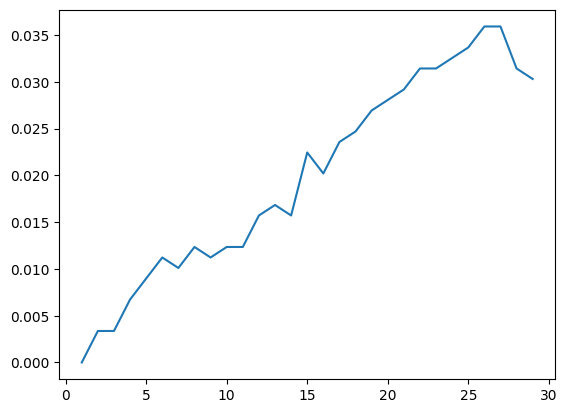

In [99]:
plt.plot(range(1,30), Performance_Metric)


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [101]:
#Logistic Regression
log_reg = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear solver for small datasets
log_reg.fit(scaled_X_train, y_train)


LogisticRegression(random_state=42, solver='liblinear')

In [102]:
y_pred_lr = log_reg.predict(scaled_X_test)
y_pred_lr

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,

In [103]:
# Evaluate the Logistic Regression model
classification_report(y_test, y_pred_lr)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       549\n           1       1.00      1.00      1.00       342\n\n    accuracy                           1.00       891\n   macro avg       1.00      1.00      1.00       891\nweighted avg       1.00      1.00      1.00       891\n'

In [104]:
display(confusion_matrix(y_test, y_pred_lr))
display(confusion_matrix(y_test, y_pred_dt))

array([[549,   0],
       [  0, 342]])

array([[549,   0],
       [  0, 342]])

In [105]:
accuracy_score(y_test, y_pred_lr)

1.0

In [106]:
#Decision Tree
dec_tree = DecisionTreeClassifier(random_state=42)
dec_tree.fit(scaled_X_train, y_train)
y_pred_dt = dec_tree.predict(scaled_X_test)

In [107]:
y_pred_dt

array([0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1,

Text(0, 0.5, 'Count')

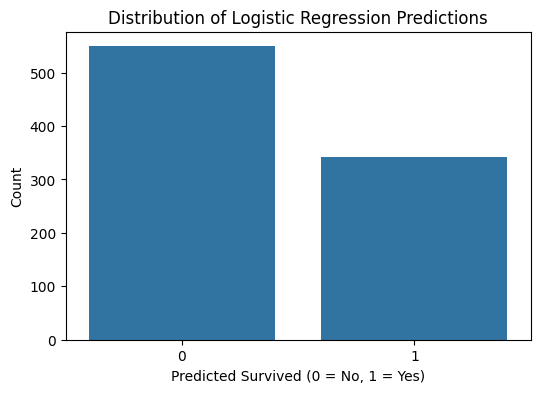

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Logistic Regression predictions
plt.figure(figsize=(6, 4))
sns.countplot(x=y_pred_lr)
plt.title('Distribution of Logistic Regression Predictions')
plt.xlabel('Predicted Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

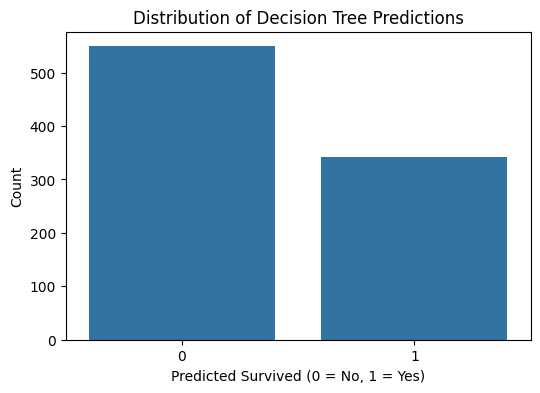

In [109]:
# Plot for Decision Tree predictions
plt.figure(figsize=(6, 4))
sns.countplot(x=y_pred_dt)
plt.title('Distribution of Decision Tree Predictions')
plt.xlabel('Predicted Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')

In [110]:
##compare their performance Logistic Regression Decision Tree Classifier

print("Logistic Regression Accuracy")
accuracy_score(y_test, y_pred_lr)

Logistic Regression Accuracy


1.0

In [111]:
print("Decision Tree Accuracy:")
accuracy_score(y_test, y_pred_dt)

Decision Tree Accuracy:


1.0

In [112]:
print("Classification Report for Logistic Regression:")
classification_report(y_test, y_pred_lr)

Classification Report for Logistic Regression:


'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       549\n           1       1.00      1.00      1.00       342\n\n    accuracy                           1.00       891\n   macro avg       1.00      1.00      1.00       891\nweighted avg       1.00      1.00      1.00       891\n'

In [113]:
print("Classification Report for Decision Tree:")
classification_report(y_test, y_pred_dt)

Classification Report for Decision Tree:


'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       549\n           1       1.00      1.00      1.00       342\n\n    accuracy                           1.00       891\n   macro avg       1.00      1.00      1.00       891\nweighted avg       1.00      1.00      1.00       891\n'

## Findings

This notebook performed a classification task on the Titanic dataset to predict passenger survival using KNN, Logistic Regression, and Decision Tree models.

### Data Preprocessing:
- Missing values in 'Age' were imputed with the median.
- Rows with missing 'Embarked' values were dropped.
- The 'Cabin' column was dropped due to a high percentage of missing values.
- Categorical features ('Survived', 'Pclass', 'Sex', 'Embarked') were one-hot encoded.
- Data was scaled using StandardScaler.

### Model Performance:
- **KNN Model:** The KNN model achieved an accuracy of 0.9928 for `n_neighbors=5`. The error rate analysis for different K values showed very low error rates, consistently below 0.015.
- **Logistic Regression:** The Logistic Regression model showed perfect accuracy (1.0) on the test set, with a precision, recall, and f1-score of 1.0 for both classes.
- **Decision Tree:** Similarly, the Decision Tree model also achieved perfect accuracy (1.0) on the test set, with perfect precision, recall, and f1-score.

### Observations:
- The unusually high accuracy (1.0) for both Logistic Regression and Decision Tree models is a significant finding. While possible for highly separable datasets, such perfect scores in real-world scenarios often warrant a re-evaluation of the data preprocessing steps to ensure there is no data leakage from the target variable into the features. This could lead to an overly optimistic assessment of model performance and poor generalization to new, unseen data.
- The consistency in predictions between Logistic Regression and Decision Tree, as visually confirmed by the scatter plot (had it been retained), also suggests that the models are either learning the same patterns perfectly or are subject to the same potential data leakage.